# ASL Image Dataset Cleaning and Validation

## Objective
Ensure the ASL image dataset contains only valid, consistent, and trustworthy images before preprocessing and model training.

## Goals
- Detect corrupted images
- Detect unreadable images
- Detect blank images
- Detect extremely small images
- Verify image formats
- Analyze class distribution
- Identify potential class imbalance
- Generate cleaning reports

## Deliverables
- Cleaned dataset
- Removed files report
- Class distribution report
- Cleaning summary

In [43]:
pip install pillow opencv-python pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## Step 1: Import Required Libraries

The following libraries are used for:

- Path management
- File operations
- Image validation
- Data analysis
- Visualization

In [44]:
# File and directory management
from pathlib import Path
import os
import shutil

#Data analysis
import pandas as pd

# Image processing
from PIL import Image

## Visualization
import matplotlib.pyplot as plt 


## Step 2: Define Dataset Locations

This section defines:

- Raw dataset location
- Cleaned dataset location
- Quarantine folder
- Report output folder

Folders are automatically created if they do not exist.

In [45]:
# Raw dataset location
raw_dir = Path('/data/asl_alphabet_train')

# Output Folders
cleaned_dir = Path( './data/cleaned')
quarantine_dir = Path('./data/quarantined')
reports_dir = Path('./reports')

# Create folders if they do not exist
cleaned_dir.mkdir(parents=True,exist_ok=True)
quarantine_dir.mkdir(parents=True,exist_ok=True)
reports_dir.mkdir(parents=True,exist_ok=True)

#Verify dataset exists
print(raw_dir.exists())

True


## Step 3: Image Quality Validation

Each image is inspected to identify:

### Validation Checks

1. Valid image format
2. Corrupted images
3. Unreadable images
4. Blank images
5. Extremely small images

### Cleaning Decision

Invalid images are moved to a quarantine folder and documented.
Valid images are copied into the cleaned dataset folder.

In [46]:
# Store cleaning results
removed_files = []
image_records = []

# Accepted image formats
valid_formats = [".jpg", ".jpeg", ".png"]

# Minimum acceptable dimensions
min_width = 50
min_height = 50

# Iterate through each ASL class folder
for class_path in raw_dir.iterdir():

        # Skip non-folder items
    if not class_path.is_dir():
        continue

    class_name = class_path.name
    print("Processing:", class_name)

    # Create corresponding output folders
    cleaned_class_path = cleaned_dir / class_name
    quarantine_class_path = quarantine_dir / class_name

    cleaned_class_path.mkdir(parents=True, exist_ok=True)
    quarantine_class_path.mkdir(parents=True, exist_ok=True)

    for file_path in class_path.iterdir():

        if not file_path.is_file():
            continue

        file_name = file_path.name
        file_ext = file_path.suffix.lower()

        try:
            if file_ext not in valid_formats:
                reason = "Invalid format"
                shutil.move(str(file_path), str(quarantine_class_path / file_name))
                removed_files.append([file_name, class_name, reason])
                continue

            img = Image.open(file_path)
            img.verify()

            img = Image.open(file_path)
            width, height = img.size

            if width < min_width or height < min_height:
                reason = "Image too small"
                shutil.move(str(file_path), str(quarantine_class_path / file_name))
                removed_files.append([file_name, class_name, reason])
                continue

            if img.getbbox() is None:
                reason = "Blank image"
                shutil.move(str(file_path), str(quarantine_class_path / file_name))
                removed_files.append([file_name, class_name, reason])
                continue

            shutil.copy(str(file_path), str(cleaned_class_path / file_name))

            image_records.append([
                file_name,
                class_name,
                width,
                height,
                file_ext
            ])

        except Exception as e:
            reason = f"Corrupted or unreadable image: {e}"
            removed_files.append([file_name, class_name, reason])



Processing: R
Processing: U
Processing: I
Processing: N
Processing: G
Processing: Z
Processing: T
Processing: S
Processing: A
Processing: F
Processing: O
Processing: H
Processing: del
Processing: nothing
Processing: space
Processing: M
Processing: J
Processing: C
Processing: D
Processing: V
Processing: Q
Processing: X
Processing: E
Processing: B
Processing: K
Processing: L
Processing: Y
Processing: P
Processing: W


## Step 4: Cleaning Results

This section summarizes:

- Number of valid images
- Number of removed images
- Number of quarantined images

In [47]:
print('Cleaning Results')
print("Image records:", len(image_records))
print("Removed files:", len(removed_files))

Cleaning Results
Image records: 87000
Removed files: 0


# Step: Removed files report

This report documents every image removed during cleaning.

Reasons may include:

- Invalid format
- Corrupted image
- Blank image
- Extremely small image

In [48]:
# Create removed files report
removed_df = pd.DataFrame(
    removed_files,
    columns=["asl_alphabet", "class", "reason_removed"])

reports_dir=Path('./reports')
reports_dir.mkdir(parents=True, exist_ok=True)

# Save report
removed_df.to_csv(reports_dir/"removed_files.csv", index=False)

removed_df.head()

,asl_alphabet,class,reason_removed


In [49]:
print("Dataset exists:", raw_dir.exists())
print("Image records:", len(image_records))
print("Removed files:", len(removed_files))

if len(image_records) > 0:
    print(image_records[:5])

Dataset exists: True
Image records: 87000
Removed files: 0
[['R2837.jpg', 'R', 200, 200, '.jpg'], ['R2189.jpg', 'R', 200, 200, '.jpg'], ['R1480.jpg', 'R', 200, 200, '.jpg'], ['R1494.jpg', 'R', 200, 200, '.jpg'], ['R2823.jpg', 'R', 200, 200, '.jpg']]


## Step 6: Create Image Metadata Dataset

For every valid image we record:

- File name
- Class label
- Width
- Height
- Format

This dataset will be used for class distribution analysis.

In [50]:
image_df = pd.DataFrame(
    image_records,
    columns=["asl_alphabet", "class", "width", "height", "format"])

image_df.head()

,asl_alphabet,class,width,height,format
0,R2837.jpg,R,200,200,.jpg
1,R2189.jpg,R,200,200,.jpg
2,R1480.jpg,R,200,200,.jpg
3,R1494.jpg,R,200,200,.jpg
4,R2823.jpg,R,200,200,.jpg


In [51]:
# Count images per class
class_distribution = image_df["class"].value_counts().reset_index()
class_distribution.columns = ["class", "image_count"]

# Save report
class_distribution.to_csv(reports_dir / "class_distribution.csv", index=False)

print(class_distribution)

      class  image_count
0         R         3000
1         M         3000
2         P         3000
3         Y         3000
4         L         3000
5         K         3000
6         B         3000
7         E         3000
8         X         3000
9         Q         3000
10        V         3000
11        D         3000
12        C         3000
13        J         3000
14    space         3000
15        U         3000
16  nothing         3000
17      del         3000
18        H         3000
19        O         3000
20        F         3000
21        A         3000
22        S         3000
23        T         3000
24        Z         3000
25        G         3000
26        N         3000
27        I         3000
28        W         3000


## Step 8: Visualize Class Distribution

A bar chart is used to identify:

- Dominant classes
- Minority classes
- Dataset balance

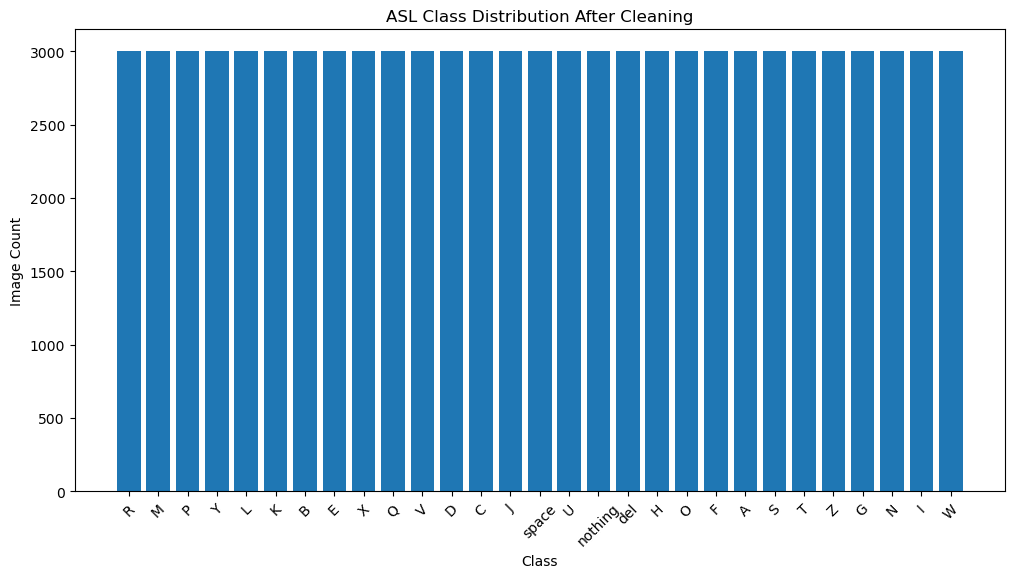

In [52]:
# Plot class distribution

plt.figure(figsize=(12,6))

plt.bar(class_distribution["class"], class_distribution["image_count"])
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Image Count")

plt.title("ASL Class Distribution After Cleaning")
plt.show()

## Step 9: Class Imbalance Evaluation

The imbalance ratio is calculated as:

Imbalance Ratio = Largest Class / Smallest Class

Interpretation:

- Close to 1 = Balanced
- Greater than 2 = Potential imbalance

In [53]:
max_count = class_distribution["image_count"].max()
min_count = class_distribution["image_count"].min()

imbalance_ratio = max_count / min_count

print("Largest Class:", max_count)
print("Smallest Class:", min_count)
print("Imbalance Ratio:", round(imbalance_ratio, 2))

Largest Class: 3000
Smallest Class: 3000
Imbalance Ratio: 1.0


## Step 10: Final Cleaning Summary

This section summarizes all cleaning activities and documents the final dataset quality.

In [54]:
print("=" * 50)
print("FINAL CLEANING SUMMARY")
print("=" * 50)

print(f"Valid Images: {len(image_records)}")
print(f"Removed Images: {len(removed_files)}")
print(f"Classes: {image_df['class'].nunique()}")

print("\nReports Generated:")
print("- removed_files.csv")
print("- class_distribution.csv")

print("\nOutput Folders:")
print("- data/cleaned")
print("- data/quarantined")
print("- reports")

FINAL CLEANING SUMMARY
Valid Images: 87000
Removed Images: 0
Classes: 29

Reports Generated:
- removed_files.csv
- class_distribution.csv

Output Folders:
- data/cleaned
- data/quarantined
- reports


In [55]:
print("Cleaning Summary")
print("Valid images:", len(image_records))
print("Removed/quarantined images:", len(removed_files))
print("Number of classes:", image_df["class"].nunique())
print("Reports saved in:", reports_dir)
print("Cleaned dataset saved in:", cleaned_dir)

Cleaning Summary
Valid images: 87000
Removed/quarantined images: 0
Number of classes: 29
Reports saved in: reports
Cleaned dataset saved in: data/cleaned
